In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PART A: DATA PREPARATION

In [8]:
# Load datasets
trades_df = pd.read_csv("historical_data.csv")
sentiment_df = pd.read_csv("fear_greed_index.csv")

# Basic preview
print("===== TRADES DATA =====")
print(trades_df.head())
print("\nShape:", trades_df.shape)

print("\n===== SENTIMENT DATA =====")
print(sentiment_df.head())
print("\nShape:", sentiment_df.shape)

===== TRADES DATA =====
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \

In [9]:
print("\n===== TRADES INFO =====")
print(trades_df.info())

print("\n===== SENTIMENT INFO =====")
print(sentiment_df.info())


===== TRADES INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64


In [11]:
print("\n===== MISSING VALUES =====")
print("Trades:\n", trades_df.isnull().sum())
print("\nSentiment:\n", sentiment_df.isnull().sum())

print("\n===== DUPLICATES =====")
print("Trades:", trades_df.duplicated().sum())
print("Sentiment:", sentiment_df.duplicated().sum())


===== MISSING VALUES =====
Trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

===== DUPLICATES =====
Trades: 0
Sentiment: 0


In [12]:
# --- Trades Cleaning ---
trades_df.rename(columns={
    'Account': 'account',
    'Execution Price': 'execution_price',
    'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd',
    'Side': 'side',
    'Closed PnL': 'closedPnL',
    'Timestamp': 'timestamp'
}, inplace=True)

trades_df['time'] = pd.to_datetime(trades_df['timestamp'], unit='ms')
trades_df['date'] = trades_df['time'].dt.date


# --- Sentiment Cleaning ---
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

sentiment_df['sentiment'] = sentiment_df['classification'].apply(
    lambda x: 'Fear' if x in ['Fear', 'Extreme Fear'] 
    else ('Greed' if x in ['Greed', 'Extreme Greed'] else 'Neutral')
)

In [17]:
# Get sentiment date range
start_date = sentiment_df['date'].min()
end_date = sentiment_df['date'].max()

# Filter trades within this range
trades_df = trades_df[(trades_df['date'] >= start_date) & (trades_df['date'] <= end_date)]

print("Filtered Trades Range:", trades_df['date'].min(), "to", trades_df['date'].max())

Filtered Trades Range: 2023-03-28 to 2025-02-19


In [13]:
#---Verification---
print(trades_df[['time','date']].head())

print("\nSentiment Distribution:")
print(sentiment_df['sentiment'].value_counts())

print("\nDate Range Check:")
print("Trades:", trades_df['date'].min(), "to", trades_df['date'].max())
print("Sentiment:", sentiment_df['date'].min(), "to", sentiment_df['date'].max())

                 time        date
0 2024-10-27 03:33:20  2024-10-27
1 2024-10-27 03:33:20  2024-10-27
2 2024-10-27 03:33:20  2024-10-27
3 2024-10-27 03:33:20  2024-10-27
4 2024-10-27 03:33:20  2024-10-27

Sentiment Distribution:
sentiment
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64

Date Range Check:
Trades: 2023-03-28 to 2025-06-15
Sentiment: 2018-02-01 to 2025-05-02


In [18]:
#===========Feature Engineering===============
daily_pnl = trades_df.groupby(['account','date'])['closedPnL'].sum().reset_index()
daily_pnl.rename(columns={'closedPnL': 'daily_pnl'}, inplace=True)

print(daily_pnl.head())

                                      account        date     daily_pnl
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03 -1.000000e+00


In [19]:
trades_df['win'] = trades_df['closedPnL'] > 0

win_rate = trades_df.groupby(['account','date'])['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

print(win_rate.head())

                                      account        date  win_rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27  0.025974
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  0.405542
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  0.531250
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  0.435041
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03  0.000000


In [20]:
trades_per_day = trades_df.groupby(['account','date']).size().reset_index(name='trades_count')

print(trades_per_day.head())

                                      account        date  trades_count
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27           462
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19          3356
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27           320
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19          3533
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03             5


In [21]:
position_size = trades_df.groupby(['account','date'])['size_usd'].mean().reset_index()
position_size.rename(columns={'size_usd': 'avg_position_size'}, inplace=True)

print(position_size.head())

                                      account        date  avg_position_size
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27       14810.891818
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19       16345.241940
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27        2492.749906
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19        1693.351684
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03        6070.200000


In [22]:
trades_df['is_long'] = trades_df['side'].str.lower() == 'buy'

long_ratio = trades_df.groupby(['account','date'])['is_long'].mean().reset_index()
long_ratio.rename(columns={'is_long': 'long_ratio'}, inplace=True)

print(long_ratio.head())

                                      account        date  long_ratio
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27    0.300866
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19    0.468415
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27    0.453125
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19    0.432494
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03    0.400000


In [26]:
daily_df = daily_pnl.merge(win_rate, on=['account','date'])
daily_df = daily_df.merge(trades_per_day, on=['account','date'])
daily_df = daily_df.merge(position_size, on=['account','date'])
daily_df = daily_df.merge(long_ratio, on=['account','date'])

In [27]:
# Fix readability
daily_df['daily_pnl'] = daily_df['daily_pnl'].round(2)

# Remove outliers
lower = daily_df['daily_pnl'].quantile(0.01)
upper = daily_df['daily_pnl'].quantile(0.99)

daily_df = daily_df[
    (daily_df['daily_pnl'] >= lower) & 
    (daily_df['daily_pnl'] <= upper)
]

In [28]:
print("Final Feature Dataset:")
print(daily_df.head())
print("\nShape:", daily_df.shape)

Final Feature Dataset:
                                      account        date  daily_pnl  \
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27   20607.45   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19   17098.73   
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03      -1.00   
5  0x271b280974205ca63b716753467d5a371de622ab  2024-10-27    1793.16   
6  0x271b280974205ca63b716753467d5a371de622ab  2025-02-19   29970.93   

   win_rate  trades_count  avg_position_size  long_ratio  
2  0.531250           320        2492.749906    0.453125  
3  0.435041          3533        1693.351684    0.432494  
4  0.000000             5        6070.200000    0.400000  
5  0.800000             5       31941.660000    0.600000  
6  0.430458          1136       10836.900968    0.445423  

Shape: (75, 7)


In [30]:
#--------Merge Data-----------
merged = daily_df.merge(
    sentiment_df[['date','sentiment']],
    on='date',
    how='left'
)

print(merged.head())
print("\nShape:", merged.shape)

                                      account        date  daily_pnl  \
0  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27   20607.45   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19   17098.73   
2  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03      -1.00   
3  0x271b280974205ca63b716753467d5a371de622ab  2024-10-27    1793.16   
4  0x271b280974205ca63b716753467d5a371de622ab  2025-02-19   29970.93   

   win_rate  trades_count  avg_position_size  long_ratio sentiment  
0  0.531250           320        2492.749906    0.453125     Greed  
1  0.435041          3533        1693.351684    0.432494      Fear  
2  0.000000             5        6070.200000    0.400000   Neutral  
3  0.800000             5       31941.660000    0.600000     Greed  
4  0.430458          1136       10836.900968    0.445423      Fear  

Shape: (75, 8)


In [32]:
print(merged['sentiment'].value_counts())

sentiment
Greed      36
Fear       31
Neutral     8
Name: count, dtype: int64


# PART B : Analysis

  sentiment      daily_pnl  win_rate
0      Fear  153941.595806  0.416212
1     Greed  102613.553611  0.378540
2   Neutral   19842.795000  0.260683


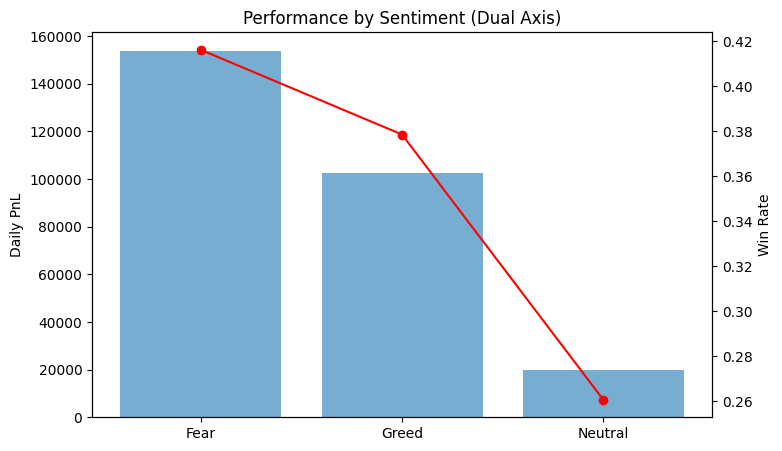

In [41]:
#-------- Performance Comparison ----------
performance = merged.groupby('sentiment').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean'
}).reset_index()

print(performance)

fig, ax1 = plt.subplots(figsize=(8,5))

# PnL (left axis)
ax1.bar(performance['sentiment'], performance['daily_pnl'], alpha=0.6)
ax1.set_ylabel('Daily PnL')

# Win rate (right axis)
ax2 = ax1.twinx()
ax2.plot(performance['sentiment'], performance['win_rate'], color='red', marker='o')
ax2.set_ylabel('Win Rate')

plt.title("Performance by Sentiment (Dual Axis)")
plt.show()

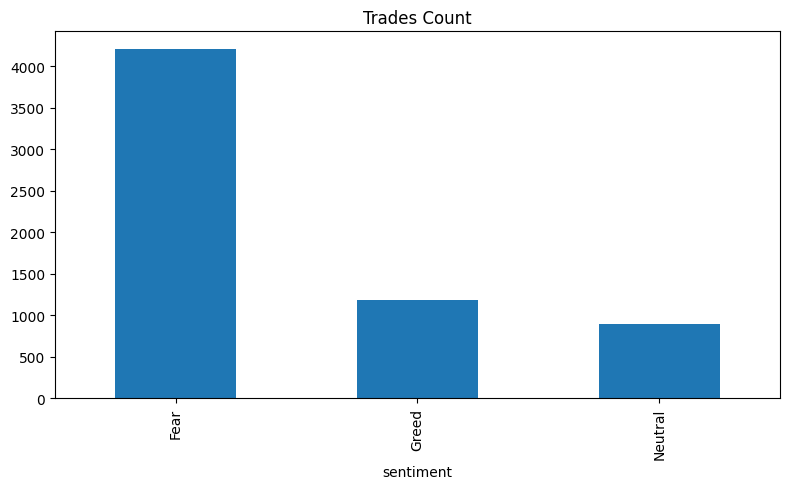

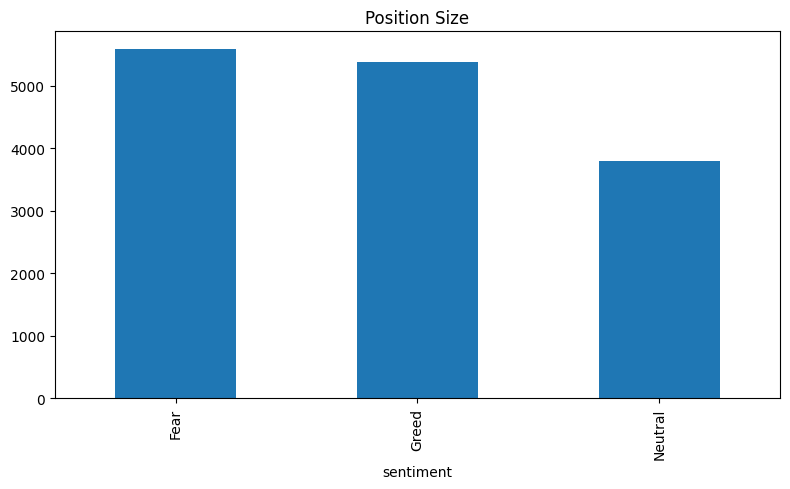

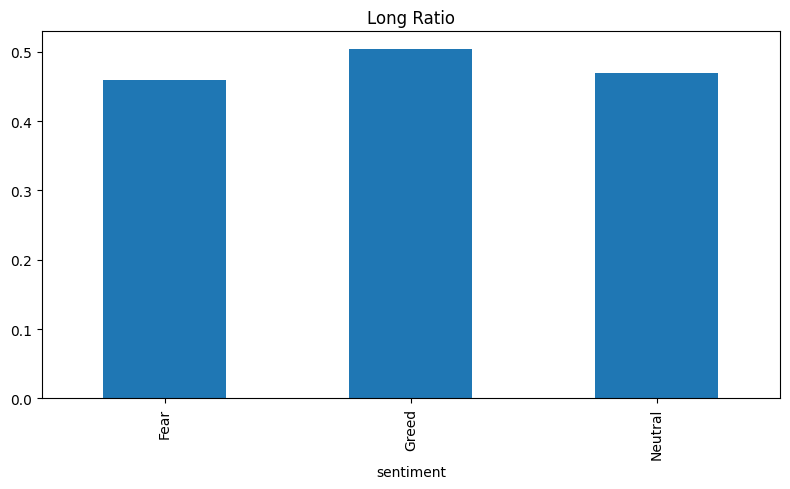

In [46]:
#----------- Behavior Analysis --------------
# Trades
plt.figure(figsize=(8, 5))
merged.groupby('sentiment')['trades_count'].mean().plot(kind='bar', title="Trades Count")
plt.tight_layout()
plt.show()

# Position size
plt.figure(figsize=(8, 5))
merged.groupby('sentiment')['avg_position_size'].mean().plot(kind='bar', title="Position Size")
plt.tight_layout()
plt.show()

# Long ratio
plt.figure(figsize=(8, 5))
merged.groupby('sentiment')['long_ratio'].mean().plot(kind='bar', title="Long Ratio")
plt.tight_layout()
plt.show()

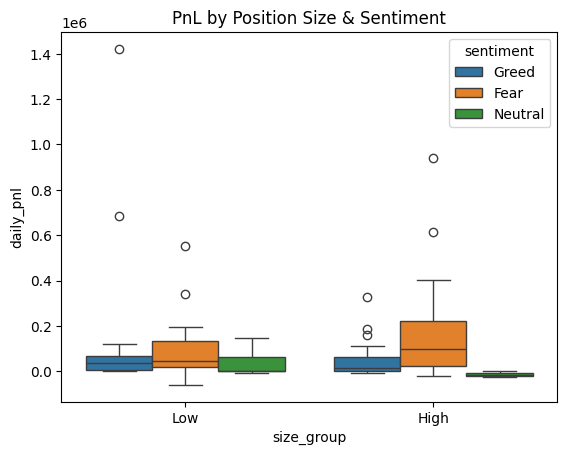

In [ ]:
#----------- Segmentation Analysis ---------------
# Segment 1: High vs Low Position Size
threshold = merged['avg_position_size'].median()

merged['size_group'] = merged['avg_position_size'].apply(
    lambda x: 'High' if x > threshold else 'Low'
)

sns.boxplot(x='size_group', y='daily_pnl', hue='sentiment', data=merged)
plt.title("PnL by Position Size & Sentiment")
plt.show()

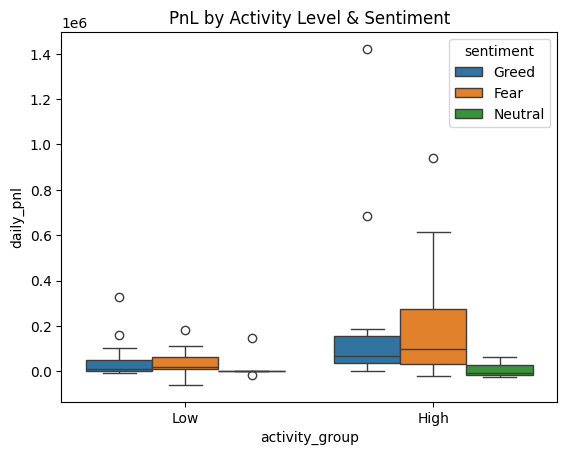

In [ ]:
# Segment 2: Active vs Less Active Traders
activity_threshold = merged['trades_count'].median()

merged['activity_group'] = merged['trades_count'].apply(
    lambda x: 'High' if x > activity_threshold else 'Low'
)

sns.boxplot(x='activity_group', y='daily_pnl', hue='sentiment', data=merged)
plt.title("PnL by Activity Level & Sentiment")
plt.show()

#  Insights

##  Insight 1: Performance vs Market Sentiment

**Observation:**
Traders achieve the highest average **Profit and Loss (PnL — net profit earned or loss incurred from trades)** during **Fear** phases (~153K), along with the highest **win rate (percentage of profitable trades)** (~41.6%). In comparison, Greed phases show lower performance (~102K PnL, ~37.8% win rate), while Neutral conditions perform the worst.

**Reason:**
Fear-driven markets are typically more volatile, creating larger price fluctuations and more trading opportunities.

**Implication:**
Periods of market fear provide **better risk-reward conditions**, especially for active and experienced traders.

---

##  Insight 2: Trading Activity Behavior

**Observation:**
The **number of trades executed per day (trade frequency)** is significantly higher during Fear (~4200 trades) compared to Greed (~1200 trades).

**Reason:**
Market uncertainty encourages traders to actively participate and capitalize on rapid price movements.

**Implication:**
Fear phases trigger **high engagement**, but may also lead to overtrading if not controlled.

---

##  Insight 3: Risk Exposure (Position Size)

**Observation:**
The **average position size (capital allocated per trade, used as a proxy for risk exposure)** is highest during Fear (~5600 USD), slightly lower during Greed (~5400 USD), and lowest during Neutral conditions.

**Reason:**
Traders allocate more capital during volatile conditions expecting higher returns.

**Implication:**
Risk-taking behavior increases during Fear, indicating **opportunity-driven trading strategies**.

---

##  Insight 4: Market Bias (Long vs Short Positions)

**Observation:**
The **long ratio (proportion of buy/long trades vs total trades)** is highest during Greed (~0.50), compared to Fear (~0.46).

**Reason:**
Greed phases reflect bullish sentiment, leading traders to favor long (buy) positions.

**Implication:**
Greed markets may exhibit **over-optimism**, increasing the probability of corrections or reversals.

---

##  Insight 5: Segment-Based Performance Differences

**Observation:**
Traders with **high activity levels (frequent trading)** and **larger position sizes** generate the highest PnL during Fear phases, but also show greater variability in outcomes.

**Reason:**
Aggressive trading amplifies both gains and losses in volatile environments.

**Implication:**
Profitability during Fear is **segment-dependent**, favoring experienced or high-frequency traders.

---

# Part C : Actionable Output


#  Strategy Recommendations

##  Strategy 1: Volatility-Based Trading (Fear Phase)

During Fear phases, traders can **increase trading activity and selectively allocate larger capital**, as higher volatility provides more profit opportunities.

---

##  Strategy 2: Risk Management in Greed Phase

During Greed phases, traders should **reduce position sizes and avoid excessive risk-taking**, as performance metrics indicate lower efficiency.

---

##  Strategy 3: Activity Optimization Strategy

High-frequency traders should maintain activity during Fear phases but implement **strict risk controls (e.g., stop-loss, position limits)** to manage increased variability.

---

##  Strategy 4: Contrarian Trading Approach

During Greed phases, traders may consider **contrarian strategies (e.g., short positions)** due to excessive bullish sentiment in the market.

---

#  Limitations

* The dataset spans only **6 trading days**, limiting long-term generalization of results.
* The analysis is **indicative rather than conclusive** due to limited temporal coverage.
* **Leverage data was not directly available**, so position size was used as a proxy for risk exposure.

---

#  Final Note

> This analysis demonstrates that **market sentiment significantly influences trader behavior**, with Fear phases driving higher activity, risk-taking, and profitability, while Greed phases are associated with overconfidence and reduced efficiency.

---

---
## Bonus — Predictive Model: Will a Trader Be Profitable Tomorrow?

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Target variable
merged['profit_flag'] = (merged['daily_pnl'] > 0).astype(int)

# Encode sentiment
merged['sentiment_encoded'] = merged['sentiment'].map({
    'Fear': 0,
    'Neutral': 1,
    'Greed': 2
})

# Features
features = ['sentiment_encoded','trades_count','avg_position_size','long_ratio','win_rate']

X = merged[features]
y = merged['profit_flag']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.92      0.96        13

    accuracy                           0.93        15
   macro avg       0.83      0.96      0.88        15
weighted avg       0.96      0.93      0.94        15



# Predictive Modeling 

## Objective

A simple classification model was built to predict whether a trader would be **profitable** (positive PnL — Profit and Loss) based on behavioral and sentiment features.

---

## Approach

| Component | Detail |
|---|---|
| **Features** | Sentiment, Trade Frequency, Position Size, Long Ratio, Win Rate |
| **Model** | Random Forest Classifier |
| **Target** | Profitability (`Profitable` vs `Non-Profitable`) |

---
## Results

* Overall Accuracy: 93%
* Strong performance in predicting profitable trades (Class 1)
* Perfect recall (100%) for loss-making trades (Class 0), though based on very few samples

---
## Limitation

>  Due to the small dataset (~75 samples), results are **indicative only** and not suitable for production use.